In [ ]:
Examen Final

Saving Tigre.jpg to Tigre.jpg
Imagen seleccionada: Tigre.jpg


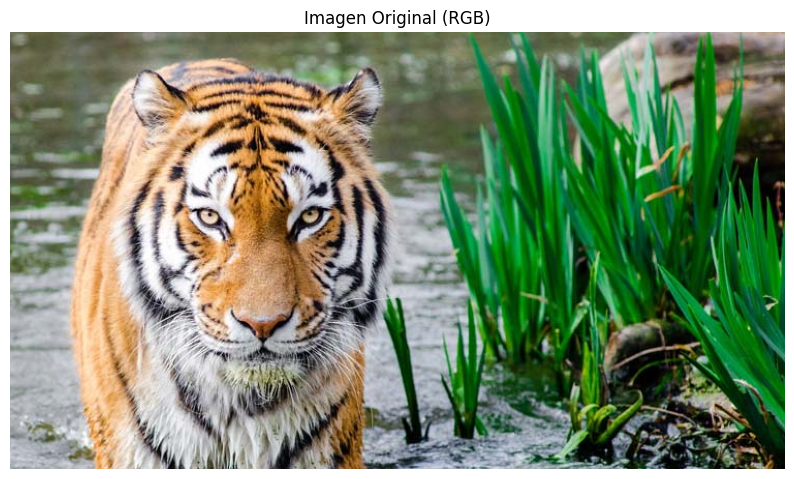

In [1]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import io
import numpy as np

# 1. Carga y visualización de una imagen (RGB) de un animal en via de extinción:

# Permite al usuario subir una imagen desde su gestor de archivos
uploaded = files.upload()

image_path = None
if uploaded:
    # Obtiene el nombre del primer archivo subido
    image_name = next(iter(uploaded))
    print(f"Imagen seleccionada: {image_name}")

    # Lee la imagen directamente desde la memoria
    img_bytes = uploaded[image_name]
    nparr = np.frombuffer(img_bytes, np.uint8)
    img_bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    # Usa el nombre del archivo para referencia, aunque la carga ya se hizo
    image_path = image_name
else:
    print("No se ha seleccionado ninguna imagen.")

# Verifica si la imagen se cargó correctamente
if img_bgr is None:
    print(f"Error: No se pudo cargar la imagen. Asegúrate de que el archivo sea una imagen válida.")
else:
    # Convierte la imagen de BGR a RGB para su correcta visualización con matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Muestra la imagen original en una figura
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title('Imagen Original (RGB)')
    plt.axis('off') # Oculta los ejes
    plt.show()


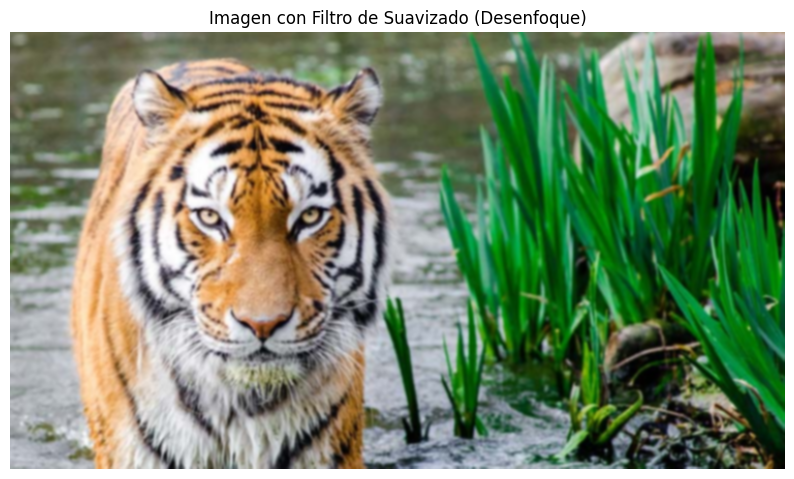

Comentario: El filtro de suavizado Gaussiano reduce el ruido y los detalles finos, haciendo que la imagen se vea más 'borrosa' o 'suave'. Las transiciones de color son menos abruptas.


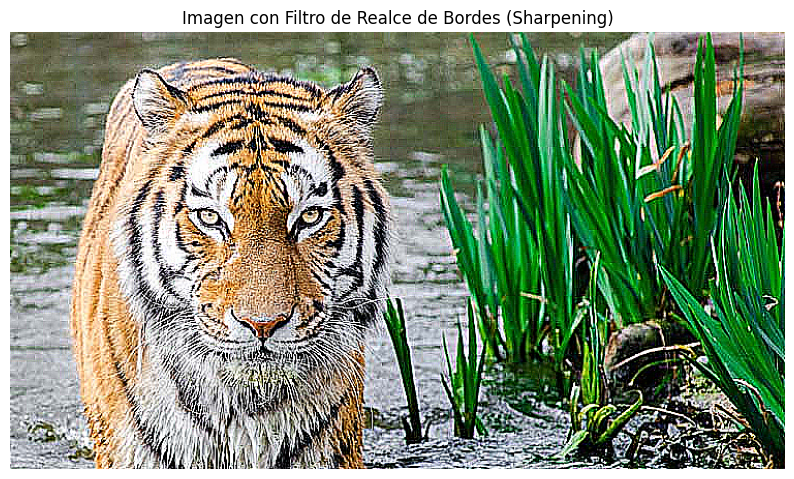

Comentario: El filtro de realce de bordes aumenta el contraste alrededor de las aristas y líneas, haciendo que los detalles y contornos de la imagen sean más definidos y visibles.


In [3]:
# 2. Filtros básicos:

if 'img_rgb' not in locals():
    print("La imagen original (img_rgb) no se ha cargado. Por favor, ejecuta la celda anterior.")
else:
    # --- 2.1 Suavizado / Desenfoque ---
    # Se utiliza un filtro Gaussiano para suavizar la imagen y reducir el ruido.
    # El tamaño del kernel (5,5) y la desviación estándar (0) determinan la intensidad del desenfoque.
    img_blurred = cv2.GaussianBlur(img_rgb, (5, 5), 0)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_blurred)
    plt.title('Imagen con Filtro de Suavizado (Desenfoque)')
    plt.axis('off')
    plt.show()
    print("Comentario: El filtro de suavizado Gaussiano reduce el ruido y los detalles finos, haciendo que la imagen se vea más 'borrosa' o 'suave'. Las transiciones de color son menos abruptas.")

    # --- 2.2 Realce de Bordes ---
    # Para el realce de bordes, se aplica un filtro de "sharpening" (nitidez).
    # Este kernel intensifica las diferencias de píxeles, resaltando los bordes.
    kernel_sharpening = np.array([[-1,-1,-1],
                                  [-1, 9,-1],
                                  [-1,-1,-1]])
    img_sharpened = cv2.filter2D(img_rgb, -1, kernel_sharpening)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_sharpened)
    plt.title('Imagen con Filtro de Realce de Bordes (Sharpening)')
    plt.axis('off')
    plt.show()
    print("Comentario: El filtro de realce de bordes aumenta el contraste alrededor de las aristas y líneas, haciendo que los detalles y contornos de la imagen sean más definidos y visibles.")


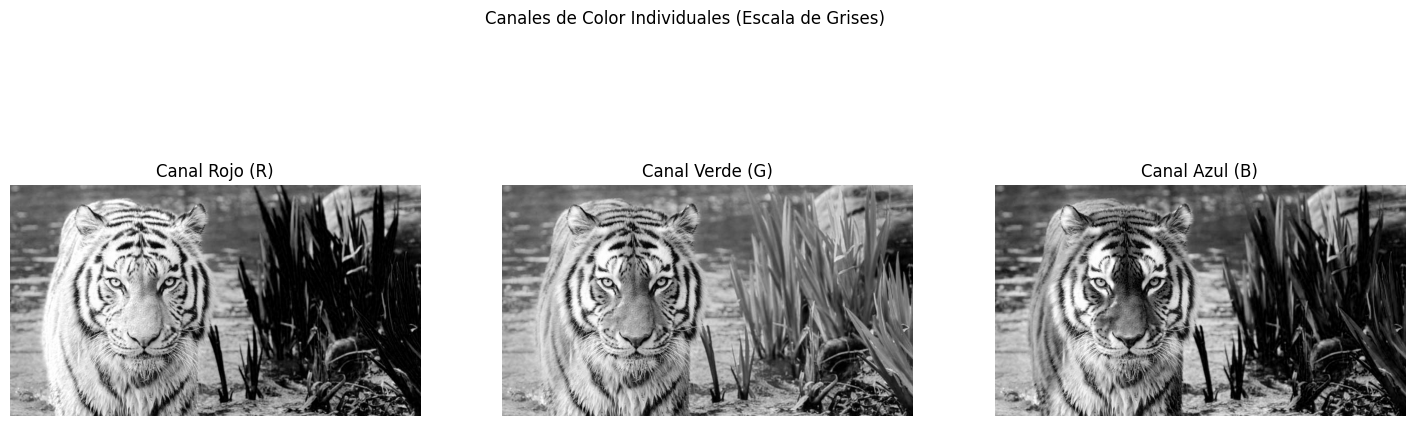


Explicación de los Canales de Color:

El canal Rojo (R) muestra las áreas con un alto componente rojo más claras y las áreas con poco rojo más oscuras. Por ejemplo, la piel de un animal anaranjado o rojizo, o ciertas flores, aparecerán brillantes.
El canal Verde (G) resalta las áreas con mucho verde. La vegetación o el pasto, por ejemplo, se verán más claros en este canal, mientras que las áreas rojas o azules serán más oscuras.
El canal Azul (B) ilumina las partes de la imagen con un fuerte componente azul. El cielo despejado o el agua tienden a verse más claros aquí. Las áreas con tonos cálidos (rojos, naranjas) suelen aparecer más oscuras.
En general, una estructura se ve más clara en un canal si contiene mucho de ese color, y más oscura si carece de él o contiene su color complementario.


In [4]:
# 3. Visualización de canales de color:

if 'img_rgb' not in locals():
    print("La imagen original (img_rgb) no se ha cargado. Por favor, ejecuta la celda de carga de imagen.")
else:
    (R, G, B) = cv2.split(img_rgb)

    # Crea una figura con tres subplots para mostrar cada canal
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Canales de Color Individuales (Escala de Grises)')

    # Muestra el canal Rojo
    axs[0].imshow(R, cmap='gray')
    axs[0].set_title('Canal Rojo (R)')
    axs[0].axis('off')

    # Muestra el canal Verde
    axs[1].imshow(G, cmap='gray')
    axs[1].set_title('Canal Verde (G)')
    axs[1].axis('off')

    # Muestra el canal Azul
    axs[2].imshow(B, cmap='gray')
    axs[2].set_title('Canal Azul (B)')
    axs[2].axis('off')

    plt.show()

    print("\nExplicación de los Canales de Color:\n")
    print("El canal Rojo (R) muestra las áreas con un alto componente rojo más claras y las áreas con poco rojo más oscuras. Por ejemplo, la piel de un animal anaranjado o rojizo, o ciertas flores, aparecerán brillantes.")
    print("El canal Verde (G) resalta las áreas con mucho verde. La vegetación o el pasto, por ejemplo, se verán más claros en este canal, mientras que las áreas rojas o azules serán más oscuras.")
    print("El canal Azul (B) ilumina las partes de la imagen con un fuerte componente azul. El cielo despejado o el agua tienden a verse más claros aquí. Las áreas con tonos cálidos (rojos, naranjas) suelen aparecer más oscuras.")
    print("En general, una estructura se ve más clara en un canal si contiene mucho de ese color, y más oscura si carece de él o contiene su color complementario.")


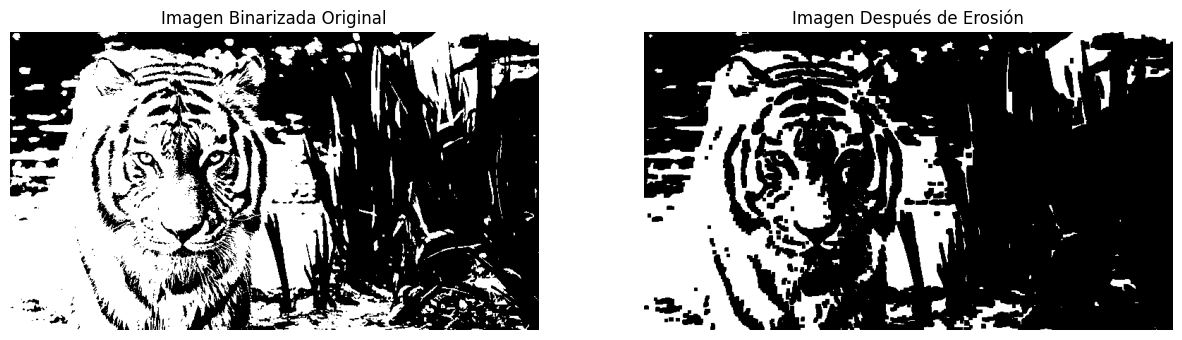


Explicación de la Erosión: La operación de erosión reduce el tamaño de las regiones de primer plano (blancas) y puede eliminar pequeños puntos de ruido o separar objetos que están ligeramente conectados. Los detalles finos y los bordes de los objetos tienden a desaparecer o a hacerse más delgados.


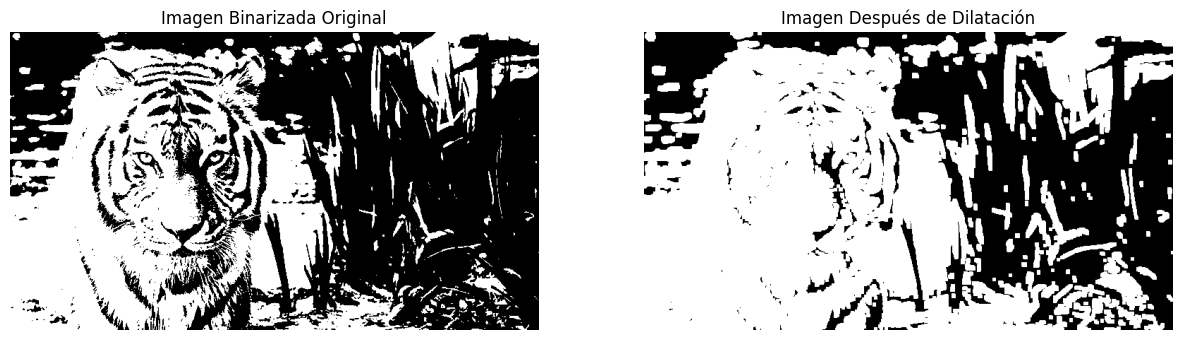


Explicación de la Dilatación: La operación de dilatación aumenta el tamaño de las regiones de primer plano (blancas). Esto puede ayudar a rellenar pequeños huecos dentro de los objetos, conectar componentes que están cerca unos de otros o hacer que los objetos se vean más robustos.


In [5]:
# 4. Operaciones Morfológicas:

if 'img_rgb' not in locals():
    print("La imagen original (img_rgb) no se ha cargado. Por favor, ejecuta la celda de carga de imagen.")
else:
    # Convertir la imagen a escala de grises para las operaciones morfológicas
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # Binarizar la imagen.
    # Se usa un umbral adaptable para manejar variaciones de iluminación.
    _, img_binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Definir un kernel para las operaciones morfológicas
    kernel = np.ones((5,5), np.uint8)

    # --- 4.1 Erosión ---
    img_eroded = cv2.erode(img_binary, kernel, iterations = 1)

    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(img_binary, cmap='gray')
    plt.title('Imagen Binarizada Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_eroded, cmap='gray')
    plt.title('Imagen Después de Erosión')
    plt.axis('off')
    plt.show()

    print("\nExplicación de la Erosión: La operación de erosión "
          "reduce el tamaño de las regiones de primer plano (blancas) y puede eliminar pequeños "
          "puntos de ruido o separar objetos que están ligeramente conectados. Los detalles finos "
          "y los bordes de los objetos tienden a desaparecer o a hacerse más delgados.")

    # --- 4.2 Dilatación ---
    img_dilated = cv2.dilate(img_binary, kernel, iterations = 1)

    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(img_binary, cmap='gray')
    plt.title('Imagen Binarizada Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_dilated, cmap='gray')
    plt.title('Imagen Después de Dilatación')
    plt.axis('off')
    plt.show()

    print("\nExplicación de la Dilatación: La operación de dilatación "
          "aumenta el tamaño de las regiones de primer plano (blancas). "
          "Esto puede ayudar a rellenar pequeños huecos dentro de los objetos, "
          "conectar componentes que están cerca unos de otros o "
          "hacer que los objetos se vean más robustos.")
